In [9]:
import xarray as xr
import pandas as pd
import os
import numpy as np

In [10]:
ds_input = xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1.zarr")
# boundary = xr.open_zarr("/pscratch/sd/a/asubel/Plots_For_Neurips/hfds_anomalies.zarr")
boundary = xr.open_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/3D_data_OM4_5daily_v0.2.1_with_hfds_anomalies/")
ds_input["hfds_anomalies"] = boundary["hfds"]
levels=19
ds_input

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 4745, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) object 1958-01-03 12:00:00 ... 2022-12-29 12:00:00
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies  (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [11]:
# dates = np.array([  3,   8,  13,  18,  23,  28,  33,  38,  43,  48,  53,  58,  63,
#         68,  73,  78,  83,  88,  93,  98, 103, 108, 113, 118, 123, 128,
#        133, 138, 143, 148, 153, 158, 163, 168, 173, 178, 183, 188, 193,
#        198, 203, 208, 213, 218, 223, 228, 233, 238, 243, 248, 253, 258,
#        263, 268, 273, 278, 283, 288, 293, 298, 303, 308, 313, 318, 323,
#        328, 333, 338, 343, 348, 353, 358, 363])
years = 100
window = 10
dates = np.array(range(3, 365*years, 5))
repeats = years // window

ds_groundtruth = ds_input.isel(lev=slice(None, levels))
# ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1996-12-31")) # 1 years
# ds_groundtruth = ds_groundtruth.sel(time=slice("1996-01-01", "1999-12-31")) # 4 years
ds_groundtruth = ds_groundtruth.sel(time=slice("1990-01-01", "1999-12-31")) # 10 years

In [23]:
# No CC
# new_time = np.array([np.datetime64('1996') + np.timedelta64(day-1,'D') for day in dates])
# for i in range(1,repeats):
#     new_time = np.hstack((new_time,np.array([np.datetime64(str(1996+i)) + np.timedelta64(day-1,'D') for day in dates])))
# ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
# ds_groundtruth['time'] = new_time[:7300]

In [5]:
# Net Zero HF CC 
new_time = np.array([np.datetime64('1990') + np.timedelta64(day-1,'D') for day in dates])
for i in range(1,repeats):
    new_time = np.hstack((new_time,np.array([np.datetime64(str(1990+i)) + np.timedelta64(day-1,'D') for day in dates])))
ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
ds_groundtruth['time'] = new_time[:7300]

/state/partition1/job-52271476/ipykernel_3923205/3462640662.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth['time'] = new_time[:7300]
/state/partition1/job-52271476/ipykernel_3923205/3462640662.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; 

In [12]:
# CC 1 with Netzero hf
new_time = np.array([np.datetime64('1990') + np.timedelta64(day-1,'D') for day in dates])
for i in range(1,repeats):
    new_time = np.hstack((new_time,np.array([np.datetime64(str(1990+i)) + np.timedelta64(day-1,'D') for day in dates])))
# new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D") 
ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
ds_groundtruth['hfds'] = ds_groundtruth['hfds'] + np.reshape(np.arange(ds_groundtruth.time.size)*(1/73),(-1,1,1))
ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] + np.reshape(np.arange(ds_groundtruth.time.size)*(1/73),(-1,1,1))
ds_groundtruth['time'] = new_time[:7300]

/state/partition1/job-52271476/ipykernel_3923205/2328750946.py:9: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth['time'] = new_time[:7300]
/state/partition1/job-52271476/ipykernel_3923205/2328750946.py:9: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; 

In [41]:
# # CC 2
# new_time = np.array([np.datetime64('1996') + np.timedelta64(day-1,'D') for day in dates])
# for i in range(1,repeats):
#     new_time = np.hstack((new_time,np.array([np.datetime64(str(1996+i)) + np.timedelta64(day-1,'D') for day in dates])))
# # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] - .12086974
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] - .12086974    
# ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] + np.reshape(2 + np.arange(ds_groundtruth.time.size)*15e-04,(-1,1,1))
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] + np.reshape(2 + np.arange(ds_groundtruth.time.size)*15e-04,(-1,1,1))
# ds_groundtruth['time'] = new_time[:7300]

/tmp/ipykernel_1040808/3580874445.py:11: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth['time'] = new_time[:7300]
/tmp/ipykernel_1040808/3580874445.py:11: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nan

In [47]:
# CC 3
# new_time = np.array([np.datetime64('1996') + np.timedelta64(day-1,'D') for day in dates])
# for i in range(1,repeats):
#     new_time = np.hstack((new_time,np.array([np.datetime64(str(1996+i)) + np.timedelta64(day-1,'D') for day in dates])))
# # new_time = pd.date_range(start=str(ds_groundtruth.time[0].values), periods=repeats * len(ds_groundtruth.time), freq="5D")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] - .12086974
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] - .12086974    
# ds_groundtruth = xr.concat([ds_groundtruth] * repeats, dim="time")
# ds_groundtruth['hfds'] = ds_groundtruth['hfds'] + np.reshape(2 + np.arange(ds_groundtruth.time.size)*75e-04,(-1,1,1))
# ds_groundtruth['hfds_anomalies'] = ds_groundtruth['hfds_anomalies'] + np.reshape(2 + np.arange(ds_groundtruth.time.size)*75e-04,(-1,1,1))
# ds_groundtruth['time'] = new_time[:7300]

/tmp/ipykernel_1040808/3921278580.py:11: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_groundtruth['time'] = new_time[:7300]
/tmp/ipykernel_1040808/3921278580.py:11: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nan

In [26]:
ds_groundtruth

<xarray.Dataset>
Dimensions:         (y: 180, x: 360, lev: 19, time: 7300, y_b: 181, x_b: 361)
Coordinates:
    areacello       (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    dz              (lev) int64 dask.array<chunksize=(19,), meta=np.ndarray>
    lat             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lat_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
  * lev             (lev) float64 2.5 10.0 22.5 40.0 ... 4e+03 5e+03 6e+03
    lon             (y, x) float64 dask.array<chunksize=(90, 360), meta=np.ndarray>
    lon_b           (y_b, x_b) float64 dask.array<chunksize=(91, 361), meta=np.ndarray>
    ocean_fraction  (lev, y, x) float64 dask.array<chunksize=(19, 180, 360), meta=np.ndarray>
  * time            (time) datetime64[ns] 1990-01-03 1990-01-08 ... 2089-12-04
    wetmask         (lev, y, x) bool dask.array<chunksize=(10, 90, 360), meta=np.ndarray>
  * x               (x) float64 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * y               (y) float64 -89.24 -88.25 -87.25 ... 87.25 88.25 89.24
Dimensions without coordinates: y_b, x_b
Data variables:
    hfds            (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    so              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    tauuo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    tauvo           (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    thetao          (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    uo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    vo              (time, lev, y, x) float32 dask.array<chunksize=(1, 19, 180, 360), meta=np.ndarray>
    zos             (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
    hfds_anomalies  (time, y, x) float32 dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes:
    m2lines/ocean-emulators_git_hash:  https://github.com/m2lines/ocean_emula...
    regrid_method:                     conservative

In [27]:
from dask.diagnostics import ProgressBar
with ProgressBar():
    ds_groundtruth.to_zarr("/vast/sd5313/data/m2lines/3D_ocean_data/OM4_5daily_v0.2.1_with_hfds_anom_100_years_10repeat_netzerohfds")

[########################################] | 100% Completed | 27m 58s


In [6]:
total_heat_flux = (ds_groundtruth['hfds']*ds_groundtruth['areacello']).sum(['x','y'])
heat_added = np.trapz(total_heat_flux.values, dx=5*3600*24)
print(heat_added)

3.5768456858715915e+22


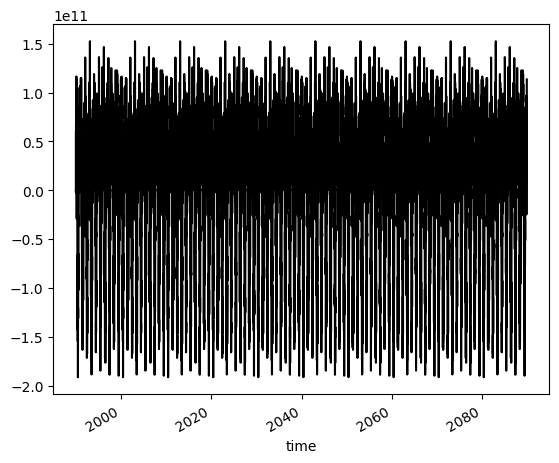

In [8]:
dim = 'time'
hfds_timeseries = (ds_groundtruth['hfds']*ds_groundtruth['areacello']).mean(['x','y'])
hfds_timeseries.plot(c='k')
poly_coeffs = hfds_timeseries.polyfit(dim=dim, deg=1)
trend = xr.polyval(hfds_timeseries[dim], poly_coeffs.polyfit_coefficients).compute()
trend.plot(c='k')

In [13]:
total_heat_flux = (ds_groundtruth['hfds']*ds_groundtruth['areacello']).sum(['x','y'])
heat_added = np.trapz(total_heat_flux.values, dx=5*3600*24)
print(heat_added)

5.919665115703995e+25


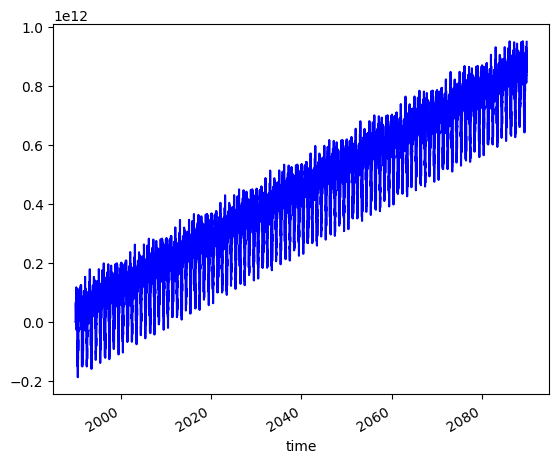

In [14]:
dim = 'time'
hfds_timeseries = (ds_groundtruth['hfds']*ds_groundtruth['areacello']).mean(['x','y'])
hfds_timeseries.plot(c='b')
poly_coeffs = hfds_timeseries.polyfit(dim=dim, deg=1)
trend = xr.polyval(hfds_timeseries[dim], poly_coeffs.polyfit_coefficients).compute()
trend.plot(c='b')